# 1. project overview, data and taxonomy

**what this notebook shows:** the 33 classes in 9 material families, how many images each class has, how the data is split, and how the training images are changed (augmented).

run the cells from top to bottom. everything here runs in about one minute.

In [1]:
# find the project folder, so the notebook works from any place
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root / "src"))
print("project folder:", root)

project folder: C:\Users\91738\edge-waste


In [2]:
# load the class list (the single source of truth for the project)
import pandas as pd
import matplotlib.pyplot as plt
from edgewaste import taxonomy as tx

print("number of classes :", tx.NUM_CLASSES)
print("number of families:", tx.NUM_FAMILIES)
print("families          :", list(tx.FAMILIES))
print("hazardous classes :", [c for c in tx.CLASS_NAMES if tx.is_hazardous(c)])

number of classes : 33
number of families: 9
families          : ['plastic', 'paper', 'cardboard', 'glass', 'metal', 'organic', 'styrofoam', 'textile', 'hazardous']
hazardous classes : ['battery', 'e_waste', 'medical']


## the split of the data

every image has one row in the split file: its path, its class and its group (train, val or test). the split is 70 / 15 / 15 and stays the same every time (seed 42).

In [3]:
# count images per class and per group
df = pd.read_csv("data/splits_colab_reconstructed.csv")
table = df.pivot_table(index="class_name", columns="split", values="path", aggfunc="count").fillna(0).astype(int)
table["total"] = table.sum(axis=1)
table = table.loc[list(tx.CLASS_NAMES)]

print("images in each group:")
print(df["split"].value_counts().to_string())
print()
print("largest class / smallest class =", round(table["total"].max() / table["total"].min(), 1), " (this is the class imbalance)")
table.head(12)

images in each group:
split
train    19739
val       4232
test      4232

largest class / smallest class = 11.6  (this is the class imbalance)


split,test,train,val,total
class_name,,,,
plastic_water_bottles,75,350,75,500
plastic_soda_bottles,75,350,75,500
plastic_detergent_bottles,75,350,75,500
plastic_food_containers,75,350,75,500
plastic_shopping_bags,75,350,75,500
plastic_trash_bags,75,350,75,500
plastic_cup_lids,75,350,75,500
plastic_straws,75,350,75,500
disposable_plastic_cutlery,75,350,75,500


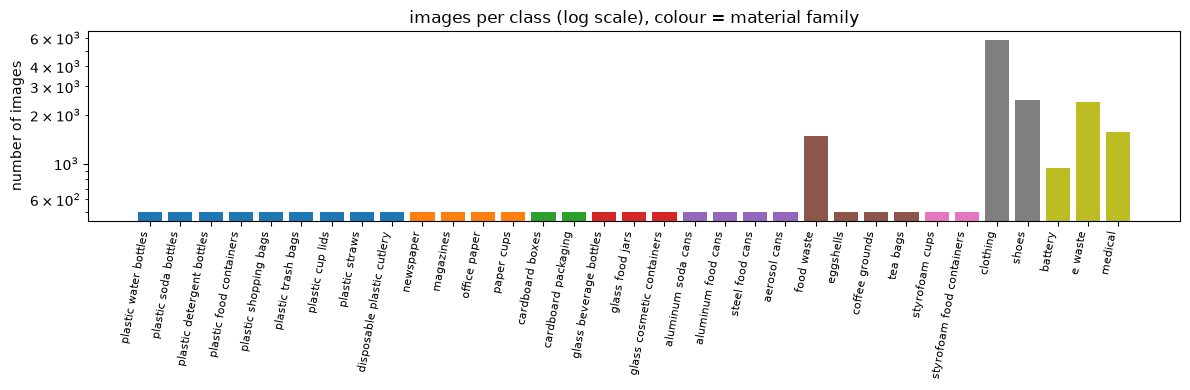

In [4]:
# bar chart of images per class, coloured by family
colors = dict(zip(tx.FAMILIES, plt.cm.tab10.colors))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(table)), table["total"], color=[colors[tx.CLASS_TO_FAMILY[c]] for c in table.index])
ax.set_xticks(range(len(table)))
ax.set_xticklabels([c.replace("_", " ") for c in table.index], rotation=80, ha="right", fontsize=8)
ax.set_ylabel("number of images")
ax.set_yscale("log")
ax.set_title("images per class (log scale), colour = material family")
plt.tight_layout()
plt.show()

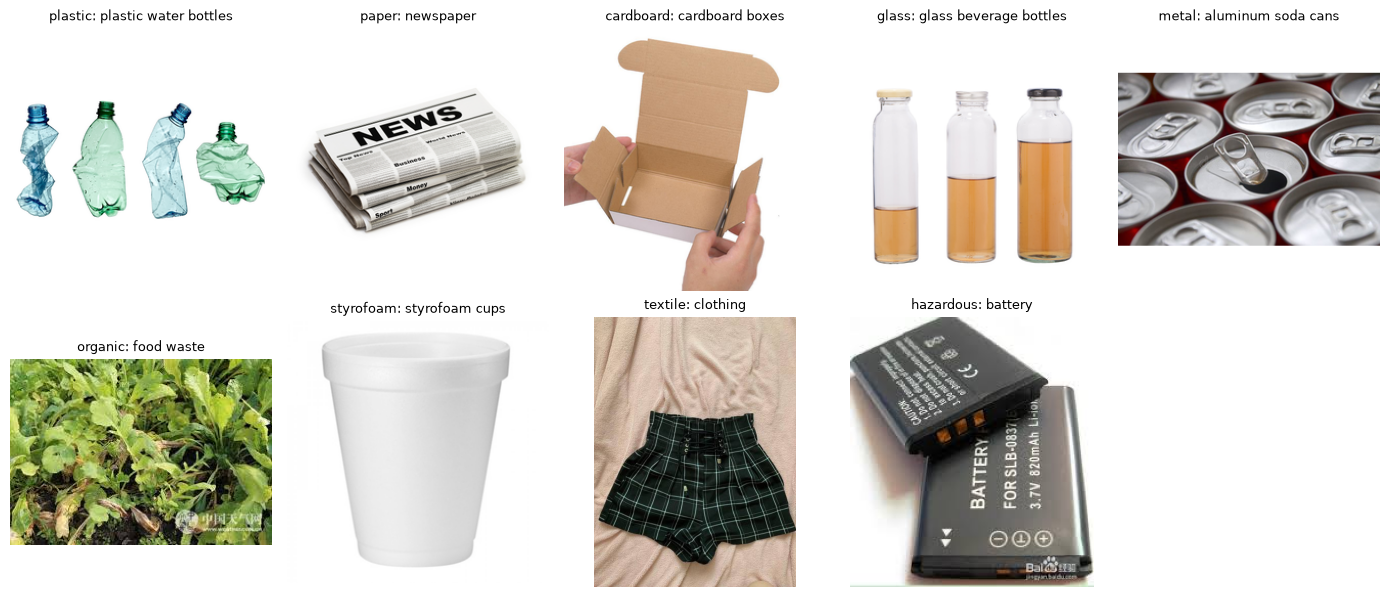

In [5]:
# show one real image from each family
from PIL import Image
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax in axes.ravel():
    ax.axis("off")
for ax, fam in zip(axes.ravel(), tx.FAMILIES):
    cls = tx.FAMILY_TO_CLASSES[fam][0]
    path = df[df["class_name"] == cls]["path"].iloc[0]
    ax.imshow(Image.open(path).convert("RGB"))
    ax.set_title(f"{fam}: {cls.replace('_', ' ')}", fontsize=9)
plt.tight_layout()
plt.show()

## why a family level?

a sorting machine has one bin for each *family*. two kinds of plastic bottle go to the same bin, so mixing them up does not matter for sorting. that is why the project reports **item accuracy** (which exact class) and **family accuracy** (which bin) separately, and **hazard recall** (are dangerous items found).

## how training images are changed (augmentation)

the training images are randomly cropped, flipped, rotated, colour-changed, blurred and partly erased. this copies real camera conditions. validation and test images are never changed.

In [6]:
# the code that builds the two image pipelines
import inspect
from edgewaste.data.waste_image_dataset import build_transforms
print(inspect.getsource(build_transforms))

def build_transforms(image_size: int, train: bool) -> transforms.Compose:
    """Augmentation per docs/planning/stage_1 Module 2: rotation, brightness, crop, blur."""
    if train:
        return transforms.Compose([
            transforms.Resize((image_size + 32, image_size + 32)),
            transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomApply(
                [transforms.GaussianBlur(kernel_size=3)], p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.1),
        ])
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])



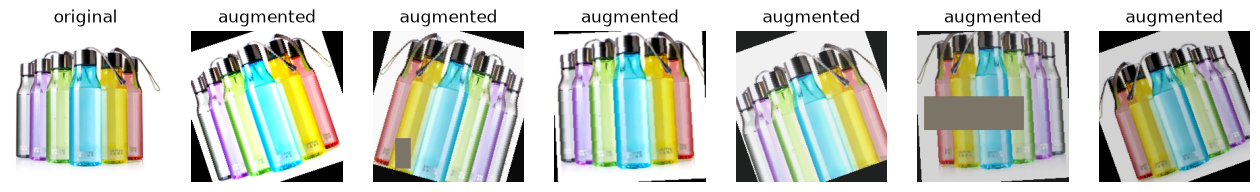

In [7]:
# the same image after 6 random augmentations
import torch
train_tfm = build_transforms(224, train=True)
img = Image.open(df[df["class_name"] == "plastic_water_bottles"]["path"].iloc[5]).convert("RGB")
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
fig, axes = plt.subplots(1, 7, figsize=(16, 3))
axes[0].imshow(img.resize((224, 224)))
axes[0].set_title("original")
for ax in axes[1:]:
    x = train_tfm(img) * std + mean          # undo the normalisation so we can look at it
    ax.imshow(x.permute(1, 2, 0).clamp(0, 1))
    ax.set_title("augmented")
for ax in axes:
    ax.axis("off")
plt.show()